In [110]:
from astroML.datasets import fetch_dr7_quasar
from astropy.table import Table, join
import numpy as np 
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
import astropy
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

### exploring the dataset

In [83]:
# Fetch the quasar data
#data = fetch_dr7_quasar()

data = np.loadtxt("dr7qso.dat.txt", skiprows=80, usecols=3)

# select the first 10000 points
#data = data[:10000]

In [84]:
data #data sono i redshift

array([1.8246, 1.8373, 1.1985, ..., 1.6937, 1.2834, 1.3542])

Text(0.5, 0, 'z')

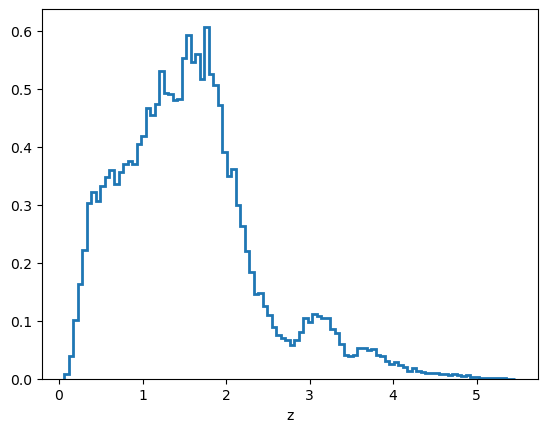

In [87]:
#plt.hist(data, bins=50)
plt.hist(data,bins=100,density=True,histtype='step',lw=2)
plt.xlabel("z")

## inverse transform

In [106]:
# 1. creation of empirical pdf
counts, bin_edges = np.histogram(data, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# calculate cdf 
dx = bin_centers[1] - bin_centers[0]
cdf = np.cumsum(counts) * dx #cumsum culative array with all the sum 
cdf = cdf / cdf[-1]  # Normalization to 1 because I divide with cdf[-1], the last element of the comulative array. It contains the sum over all the bins 

# creation of inverse function interpolating cdf
inv_cdf = scipy.interpolate.interp1d(cdf, bin_centers, bounds_error=False, fill_value="extrapolate")

# cloned sample
N = 100000 
u = np.random.uniform(min(cdf), max(cdf), size=N)
cloned_data = inv_cdf(u)

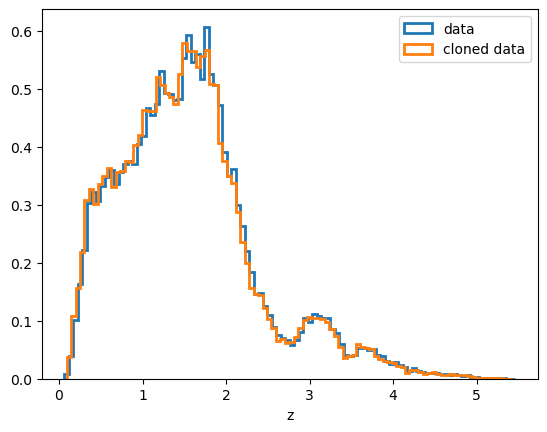

In [108]:
plt.hist(data,bins=100,density=True,histtype='step',lw=2, label="data")
plt.hist(cloned_data,bins=100,density=True,histtype='step',lw=2, label="cloned data")
plt.xlabel("z")
plt.legend()

In [114]:
z_theo = np.linspace(0,5,100000)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_theo).value

Text(0, 0.5, 'comoving volume')

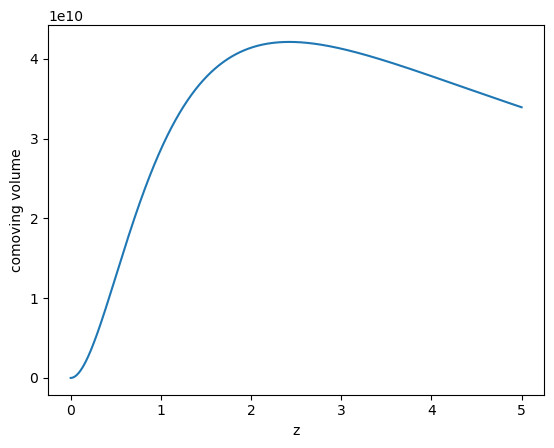

In [120]:
plt.plot(z_theo, comvol, label="theoretical model")
plt.xlabel("z")
plt.ylabel("comoving volume")